# TinyViT Explainability: GradCAM Comparison

This notebook compares GradCAM visualizations across different training strategies:

1. **Teacher** (ViT-Base finetuned on CIFAR-100 - the model used for distillation pretraining)
2. **Student - Logits Only** (TinyViT-5M distilled with logits from ViT-Base)
3. **Student - Logits + Features** (TinyViT-5M distilled with logits + features)
4. **Baseline** (TinyViT-5M trained from scratch, if available)

## Key Insight
GradCAM for Vision Transformers requires special handling since they don't have traditional CNN feature maps:
- **ViT-Base**: Pure transformer with CLS token. We target `model.blocks[-1]` and remove the CLS token before reshaping. Spatial size: 14x14 (224/16 patch size).
- **TinyViT**: Hybrid CNN+Transformer. We target `model.layers[-1]` (last transformer block). Spatial size: 7x7.

## Supported Models
- `vit_base` / `vit_base_patch16_224`: ViT-Base from timm
- `tiny_vit_5m`: TinyViT-5M (~5.4M params)
- `tiny_vit_21m`: TinyViT-21M (~21M params)

## 1. Setup

In [9]:
#@title Imports
import os
import sys
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from typing import Optional, List, Dict, Tuple
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR100

# Add project root to path
PROJECT_ROOT = os.path.dirname(os.path.abspath('.'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, '.')

from config import get_config
from models import build_model

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [10]:
#@title CIFAR-100 Class Names
CIFAR100_CLASSES = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle',
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel',
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock',
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster',
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose',
    'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
    'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
    'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

## 2. GradCAM for TinyViT

TinyViT is a hybrid architecture with both CNN (MBConv) and Transformer blocks. We need to handle the attention-based layers differently from pure CNNs.

In [11]:
#@title GradCAM Implementation (TinyViT + ViT-Base Compatible)

class GradCAM:
    """
    Grad-CAM implementation compatible with both TinyViT and ViT-Base architectures.
    
    For TinyViT: Targets the last transformer block output (model.layers[-1])
    For ViT-Base: Targets the last transformer block (model.blocks[-1])
    """
    
    def __init__(
        self, 
        model: torch.nn.Module, 
        target_layer: torch.nn.Module,
        model_type: str = 'tiny_vit'  # 'tiny_vit' or 'vit_base'
    ):
        """
        Args:
            model: The model
            target_layer: Layer to compute GradCAM on
            model_type: 'tiny_vit' or 'vit_base' (affects reshape transform)
        """
        self.model = model
        self.target_layer = target_layer
        self.model_type = model_type
        self.feature_maps = None
        self.gradients = None
        self.handles = []
        
        # Register hooks
        self.handles.append(
            self.target_layer.register_forward_hook(self._save_feature_maps)
        )
        self.handles.append(
            self.target_layer.register_full_backward_hook(self._save_gradients)
        )
    
    def _save_feature_maps(self, module, input, output):
        """Save feature maps during forward pass."""
        self.feature_maps = output.detach()
    
    def _save_gradients(self, module, grad_input, grad_output):
        """Save gradients during backward pass."""
        self.gradients = grad_output[0].detach()
    
    def _reshape_transform(
        self, 
        tensor: torch.Tensor, 
        height: int, 
        width: int
    ) -> torch.Tensor:
        """
        Reshape tensor from [B, H*W, C] or [B, H*W+1, C] to [B, C, H, W].
        
        For ViT: Remove CLS token (first token) before reshaping.
        For TinyViT: No CLS token, direct reshape.
        """
        if tensor.dim() == 3:
            B, N, C = tensor.shape
            
            # ViT-Base has CLS token as first token
            if self.model_type == 'vit_base' and N == height * width + 1:
                # Remove CLS token
                tensor = tensor[:, 1:, :]
                N = N - 1
            
            # Reshape [B, H*W, C] -> [B, C, H, W]
            if N == height * width:
                tensor = tensor.permute(0, 2, 1).reshape(B, C, height, width)
            else:
                # Fallback: interpolate to target size
                tensor = tensor.permute(0, 2, 1)  # [B, C, N]
                tensor = tensor.unsqueeze(-1)  # [B, C, N, 1]
                tensor = F.interpolate(tensor, size=(height * width, 1), mode='bilinear', align_corners=False)
                tensor = tensor.squeeze(-1).reshape(B, C, height, width)
        
        return tensor
    
    def generate_cam(
        self, 
        input_image: torch.Tensor, 
        target_class: Optional[int] = None,
        spatial_size: Tuple[int, int] = (7, 7)
    ) -> np.ndarray:
        """
        Generate Grad-CAM heatmap.
        
        Args:
            input_image: Input tensor [1, 3, 224, 224]
            target_class: Class index for CAM. If None, uses predicted class.
            spatial_size: Expected spatial size of feature maps (H, W)
        
        Returns:
            cam: Normalized heatmap [224, 224]
        """
        self.model.zero_grad()
        
        # Forward pass
        output = self.model(input_image)
        
        # Use predicted class if not specified
        if target_class is None:
            target_class = output.argmax(dim=1).item()
        
        # Backward pass for target class
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1
        output.backward(gradient=one_hot, retain_graph=True)
        
        # Get feature maps and gradients
        feature_maps = self.feature_maps
        gradients = self.gradients
        
        # Reshape if needed (for transformer outputs)
        H, W = spatial_size
        feature_maps = self._reshape_transform(feature_maps, H, W)
        gradients = self._reshape_transform(gradients, H, W)
        
        # Compute weights via global average pooling of gradients
        weights = torch.mean(gradients, dim=(2, 3), keepdim=True)
        
        # Weighted combination of feature maps
        cam = torch.sum(weights * feature_maps, dim=1, keepdim=True)
        
        # ReLU - only positive contributions
        cam = F.relu(cam)
        
        # Upsample to input size
        cam = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
        
        # Normalize to [0, 1]
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        
        return cam
    
    def remove_hooks(self):
        """Remove registered hooks."""
        for handle in self.handles:
            handle.remove()


def get_target_layer(model, model_type: str = 'tiny_vit'):
    """
    Get the appropriate target layer for GradCAM based on model type.
    
    Args:
        model: The model
        model_type: 'tiny_vit_5m', 'tiny_vit_21m', or 'vit_base'
    
    Returns:
        Target layer for GradCAM
    """
    # Handle DDP wrapper
    if hasattr(model, 'module'):
        model = model.module
    
    if model_type in ['tiny_vit_5m', 'tiny_vit_21m', 'tiny_vit']:
        # TinyViT: layers[-1] is the last stage (transformer blocks)
        return model.layers[-1]
    elif model_type == 'vit_base':
        # ViT-Base: blocks[-1] is the last transformer block
        return model.blocks[-1]
    else:
        raise ValueError(f"Unknown model type: {model_type}")


def get_spatial_size(model_type: str = 'tiny_vit_5m') -> Tuple[int, int]:
    """
    Get the spatial feature map size for different models.
    
    For 224x224 input:
    - TinyViT: 7x7 (after patch_embed and stages)
    - ViT-Base: 14x14 (224/16 patch size)
    """
    if model_type in ['tiny_vit_5m', 'tiny_vit_21m', 'tiny_vit']:
        return (7, 7)
    elif model_type == 'vit_base':
        return (14, 14)
    else:
        return (7, 7)


def get_gradcam_model_type(model_type: str) -> str:
    """Map model type to GradCAM model type."""
    if model_type in ['tiny_vit_5m', 'tiny_vit_21m', 'tiny_vit']:
        return 'tiny_vit'
    elif model_type in ['vit_base', 'vit_base_patch16_224']:
        return 'vit_base'
    else:
        return 'tiny_vit'


# Keep legacy function for backwards compatibility
def get_tinyvit_target_layer(model):
    return get_target_layer(model, 'tiny_vit')


def get_spatial_size_for_tinyvit(model_type: str = 'tiny_vit_5m') -> Tuple[int, int]:
    return get_spatial_size(model_type)

## 3. Model Loading Utilities

In [12]:
#@title Model Loading Functions (TinyViT + ViT-Base)

import timm

def load_tinyvit_model(
    checkpoint_path: str,
    model_type: str = 'tiny_vit_5m',
    num_classes: int = 100,
    device: torch.device = device
) -> torch.nn.Module:
    """
    Load a TinyViT model from checkpoint.
    
    Args:
        checkpoint_path: Path to .pth checkpoint
        model_type: 'tiny_vit_5m' or 'tiny_vit_21m'
        num_classes: Number of output classes
        device: Device to load model on
    
    Returns:
        Loaded model in eval mode
    """
    from models.tiny_vit import TinyViT
    
    # Model configurations
    configs = {
        'tiny_vit_5m': {
            'embed_dims': [64, 128, 160, 320],
            'depths': [2, 2, 6, 2],
            'num_heads': [2, 4, 5, 10],
            'window_sizes': [7, 7, 14, 7],
        },
        'tiny_vit_21m': {
            'embed_dims': [96, 192, 384, 576],
            'depths': [2, 2, 6, 2],
            'num_heads': [3, 6, 12, 18],
            'window_sizes': [7, 7, 14, 7],
        },
    }
    
    cfg = configs[model_type]
    
    model = TinyViT(
        img_size=224,
        num_classes=num_classes,
        embed_dims=cfg['embed_dims'],
        depths=cfg['depths'],
        num_heads=cfg['num_heads'],
        window_sizes=cfg['window_sizes'],
    )
    
    # Load checkpoint
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    if 'model' in checkpoint:
        state_dict = checkpoint['model']
    else:
        state_dict = checkpoint
    
    model.load_state_dict(state_dict, strict=False)
    model = model.to(device)
    model.eval()
    
    print(f"Loaded {model_type} from {checkpoint_path}")
    return model


def load_vit_base_model(
    checkpoint_path: str,
    num_classes: int = 100,
    device: torch.device = device,
    pretrained: bool = False
) -> torch.nn.Module:
    """
    Load a ViT-Base model from checkpoint.
    
    ViT-Base uses timm library. The model has:
    - patch_size=16, embed_dim=768, depth=12, num_heads=12
    - Spatial size: 14x14 (for 224x224 input)
    
    Args:
        checkpoint_path: Path to .pth checkpoint
        num_classes: Number of output classes
        device: Device to load model on
        pretrained: Whether to load ImageNet pretrained weights first
    
    Returns:
        Loaded model in eval mode
    """
    # Create ViT-Base model via timm
    model = timm.create_model(
        'vit_base_patch16_224',
        pretrained=pretrained,
        num_classes=num_classes,
    )
    
    # Load checkpoint if provided
    if checkpoint_path and os.path.exists(checkpoint_path):
        checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
        if 'model' in checkpoint:
            state_dict = checkpoint['model']
        else:
            state_dict = checkpoint
        
        # Handle potential size mismatch in head
        model_state = model.state_dict()
        for key in ['head.weight', 'head.bias']:
            if key in state_dict and key in model_state:
                if state_dict[key].shape != model_state[key].shape:
                    print(f"Skipping {key} due to shape mismatch: {state_dict[key].shape} vs {model_state[key].shape}")
                    del state_dict[key]
        
        model.load_state_dict(state_dict, strict=False)
        print(f"Loaded vit_base from {checkpoint_path}")
    else:
        print(f"Created vit_base (checkpoint not found: {checkpoint_path})")
    
    model = model.to(device)
    model.eval()
    
    return model


def load_model(
    checkpoint_path: str,
    model_type: str,
    num_classes: int = 100,
    device: torch.device = device
) -> torch.nn.Module:
    """
    Universal model loading function.
    
    Args:
        checkpoint_path: Path to .pth checkpoint
        model_type: 'tiny_vit_5m', 'tiny_vit_21m', or 'vit_base'
        num_classes: Number of output classes
        device: Device to load model on
    
    Returns:
        Loaded model in eval mode
    """
    if model_type in ['tiny_vit_5m', 'tiny_vit_21m']:
        return load_tinyvit_model(checkpoint_path, model_type, num_classes, device)
    elif model_type in ['vit_base', 'vit_base_patch16_224']:
        return load_vit_base_model(checkpoint_path, num_classes, device)
    else:
        raise ValueError(f"Unknown model type: {model_type}")


class ModelRegistry:
    """
    Registry to manage multiple models for comparison.
    Supports both TinyViT and ViT-Base models.
    """
    
    def __init__(self):
        self.models: Dict[str, torch.nn.Module] = {}
        self.model_types: Dict[str, str] = {}
    
    def register(
        self, 
        name: str, 
        checkpoint_path: str, 
        model_type: str = 'tiny_vit_5m',
        num_classes: int = 100
    ):
        """
        Register a model by name.
        
        Args:
            name: Display name for the model
            checkpoint_path: Path to checkpoint
            model_type: 'tiny_vit_5m', 'tiny_vit_21m', or 'vit_base'
            num_classes: Number of output classes
        """
        if os.path.exists(checkpoint_path):
            self.models[name] = load_model(
                checkpoint_path, model_type, num_classes
            )
            self.model_types[name] = model_type
            print(f"  -> Registered as '{name}'")
        else:
            print(f"  -> Checkpoint not found: {checkpoint_path}")
    
    def get(self, name: str) -> Optional[torch.nn.Module]:
        """Get model by name."""
        return self.models.get(name)
    
    def get_model_type(self, name: str) -> str:
        """Get model type by name."""
        return self.model_types.get(name, 'tiny_vit_5m')
    
    def list_models(self) -> List[str]:
        """List all registered model names."""
        return list(self.models.keys())
    
    def __len__(self):
        return len(self.models)

## 4. Visualization Utilities

In [13]:
#@title Visualization Functions (Multi-architecture Support)

# CIFAR-100 normalization (used during training)
CIFAR_MEAN = torch.tensor([0.5071, 0.4867, 0.4408]).view(1, 3, 1, 1)
CIFAR_STD = torch.tensor([0.2675, 0.2565, 0.2761]).view(1, 3, 1, 1)

def get_cifar_transform():
    """Get transform for CIFAR-100 images."""
    return transforms.Compose([
        transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5071, 0.4867, 0.4408], 
                           std=[0.2675, 0.2565, 0.2761]),
    ])


def denormalize_image(tensor: torch.Tensor) -> np.ndarray:
    """
    Convert normalized tensor back to displayable image.
    
    Args:
        tensor: Normalized image tensor [1, 3, H, W]
    
    Returns:
        RGB image array [H, W, 3] in range [0, 1]
    """
    tensor = tensor.cpu()
    img = tensor * CIFAR_STD + CIFAR_MEAN
    img = img.squeeze().permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    return img


def overlay_cam_on_image(
    image: np.ndarray, 
    cam: np.ndarray, 
    alpha: float = 0.5,
    colormap: str = 'jet'
) -> np.ndarray:
    """
    Overlay CAM heatmap on original image.
    
    Args:
        image: Original image [H, W, 3]
        cam: CAM heatmap [H, W]
        alpha: Transparency for heatmap
        colormap: Matplotlib colormap name
    
    Returns:
        Overlaid image [H, W, 3]
    """
    cmap = plt.cm.get_cmap(colormap)
    heatmap = cmap(cam)[:, :, :3]  # Remove alpha channel
    
    overlaid = (1 - alpha) * image + alpha * heatmap
    return np.clip(overlaid, 0, 1)


def visualize_single_model(
    model: torch.nn.Module,
    model_type: str,
    image_tensor: torch.Tensor,
    original_image: np.ndarray,
    true_label: int,
    model_name: str = "Model",
    top_k: int = 3,
    ax_row: List = None
):
    """
    Generate GradCAM visualizations for a single model.
    
    Args:
        model: The model to visualize
        model_type: 'tiny_vit_5m', 'tiny_vit_21m', or 'vit_base'
        image_tensor: Normalized input tensor [1, 3, 224, 224]
        original_image: Denormalized image for display [224, 224, 3]
        true_label: Ground truth class index
        model_name: Name for display
        top_k: Number of top predictions to show
        ax_row: List of matplotlib axes to plot on
    """
    target_layer = get_target_layer(model, model_type)
    spatial_size = get_spatial_size(model_type)
    gradcam_type = get_gradcam_model_type(model_type)
    
    grad_cam = GradCAM(model, target_layer, model_type=gradcam_type)
    
    # Get predictions
    with torch.no_grad():
        output = model(image_tensor)
        probs = F.softmax(output, dim=1)
    
    # Top-k predictions
    top_probs, top_indices = torch.topk(probs, top_k)
    top_probs = top_probs[0].cpu().numpy()
    top_indices = top_indices[0].cpu().numpy()
    
    predicted_class = top_indices[0]
    
    # Generate CAM for predicted class
    cam = grad_cam.generate_cam(image_tensor, predicted_class, spatial_size)
    overlaid = overlay_cam_on_image(original_image, cam)
    
    # Plot
    if ax_row is not None:
        # CAM overlay
        ax_row[0].imshow(overlaid)
        ax_row[0].set_title(f"{model_name}\nPred: {CIFAR100_CLASSES[predicted_class]}\n({top_probs[0]*100:.1f}%)")
        ax_row[0].axis('off')
        
        # Heatmap only
        ax_row[1].imshow(cam, cmap='jet')
        ax_row[1].set_title(f"Heatmap")
        ax_row[1].axis('off')
    
    grad_cam.remove_hooks()
    
    return {
        'predicted_class': predicted_class,
        'predicted_prob': top_probs[0],
        'top_k_classes': top_indices,
        'top_k_probs': top_probs,
        'cam': cam,
        'correct': predicted_class == true_label
    }


def compare_models(
    registry: ModelRegistry,
    image_tensor: torch.Tensor,
    original_image: np.ndarray,
    true_label: int,
    sample_idx: int = 0,
    figsize: Tuple[int, int] = (16, 4)
):
    """
    Compare GradCAM across all registered models.
    
    Args:
        registry: ModelRegistry with loaded models
        image_tensor: Input image tensor
        original_image: Denormalized image for display
        true_label: Ground truth class
        sample_idx: Sample index for title
        figsize: Figure size
    """
    model_names = registry.list_models()
    n_models = len(model_names)
    
    if n_models == 0:
        print("No models registered!")
        return
    
    # Create figure: 1 row for original + n_models rows for CAMs
    fig, axes = plt.subplots(1, n_models + 1, figsize=figsize)
    
    # Original image
    axes[0].imshow(original_image)
    axes[0].set_title(f"Original\nTrue: {CIFAR100_CLASSES[true_label]}")
    axes[0].axis('off')
    
    # GradCAM for each model
    results = {}
    for i, name in enumerate(model_names):
        model = registry.get(name)
        model_type = registry.get_model_type(name)
        
        target_layer = get_target_layer(model, model_type)
        spatial_size = get_spatial_size(model_type)
        gradcam_type = get_gradcam_model_type(model_type)
        
        grad_cam = GradCAM(model, target_layer, model_type=gradcam_type)
        
        # Get prediction
        with torch.no_grad():
            output = model(image_tensor)
            probs = F.softmax(output, dim=1)
        
        predicted_class = probs.argmax(dim=1).item()
        predicted_prob = probs[0, predicted_class].item()
        
        # Generate CAM
        cam = grad_cam.generate_cam(image_tensor, predicted_class, spatial_size)
        overlaid = overlay_cam_on_image(original_image, cam)
        
        # Plot
        axes[i + 1].imshow(overlaid)
        correct = "checkmark" if predicted_class == true_label else "X"
        color = "green" if predicted_class == true_label else "red"
        axes[i + 1].set_title(
            f"{name}\n{CIFAR100_CLASSES[predicted_class]}\n({predicted_prob*100:.1f}%)",
            color=color
        )
        axes[i + 1].axis('off')
        
        results[name] = {
            'predicted': predicted_class,
            'prob': predicted_prob,
            'correct': predicted_class == true_label,
            'cam': cam
        }
        
        grad_cam.remove_hooks()
    
    plt.suptitle(f"Sample {sample_idx}: {CIFAR100_CLASSES[true_label]}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
    
    return results


def compare_models_detailed(
    registry: ModelRegistry,
    image_tensor: torch.Tensor,
    original_image: np.ndarray,
    true_label: int,
    sample_idx: int = 0
):
    """
    Detailed comparison showing heatmaps separately.
    """
    model_names = registry.list_models()
    n_models = len(model_names)
    
    if n_models == 0:
        print("No models registered!")
        return
    
    fig, axes = plt.subplots(2, n_models + 1, figsize=(4 * (n_models + 1), 8))
    
    # Original image (spans both rows conceptually)
    axes[0, 0].imshow(original_image)
    axes[0, 0].set_title(f"Original\nTrue: {CIFAR100_CLASSES[true_label]}")
    axes[0, 0].axis('off')
    axes[1, 0].axis('off')  # Empty
    
    for i, name in enumerate(model_names):
        model = registry.get(name)
        model_type = registry.get_model_type(name)
        
        target_layer = get_target_layer(model, model_type)
        spatial_size = get_spatial_size(model_type)
        gradcam_type = get_gradcam_model_type(model_type)
        
        grad_cam = GradCAM(model, target_layer, model_type=gradcam_type)
        
        with torch.no_grad():
            output = model(image_tensor)
            probs = F.softmax(output, dim=1)
        
        predicted_class = probs.argmax(dim=1).item()
        predicted_prob = probs[0, predicted_class].item()
        
        cam = grad_cam.generate_cam(image_tensor, predicted_class, spatial_size)
        overlaid = overlay_cam_on_image(original_image, cam)
        
        # Top row: Overlay
        axes[0, i + 1].imshow(overlaid)
        color = "green" if predicted_class == true_label else "red"
        axes[0, i + 1].set_title(
            f"{name}\n{CIFAR100_CLASSES[predicted_class]} ({predicted_prob*100:.1f}%)",
            color=color
        )
        axes[0, i + 1].axis('off')
        
        # Bottom row: Heatmap
        im = axes[1, i + 1].imshow(cam, cmap='jet', vmin=0, vmax=1)
        axes[1, i + 1].set_title("Attention Map")
        axes[1, i + 1].axis('off')
        
        grad_cam.remove_hooks()
    
    plt.suptitle(f"Sample {sample_idx}: {CIFAR100_CLASSES[true_label]}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

## 5. Load Models

In [25]:
#@title Configure Checkpoint Paths

# ============================================================================
# UPDATE THESE PATHS TO YOUR CHECKPOINTS
# ============================================================================

#@markdown ### Teacher Model (ViT-Base - used for distillation pretraining)
TEACHER_CHECKPOINT = r"C:\Users\ilyas\TinyViT\Cream\TinyViT\output\P1_teacher_tinyvit21m\Exp3-TinyViT21M-Teacher\default\ckpt_epoch_30.pth"  #@param {type:"string"}
TEACHER_MODEL_TYPE = "tiny_vit_21m"  #@param ["vit_base", "tiny_vit_21m"]

#@markdown ### Student - Logits Only (TinyViT-5M)
STUDENT_LOGITS_CHECKPOINT = r"C:\Users\ilyas\TinyViT\Cream\TinyViT\output\P4_online_logits_only\Exp10a-Online-LogitsOnly\default\ckpt_epoch_100.pth"  #@param {type:"string"}

#@markdown ### Student - Logits + Features (TinyViT-5M)
STUDENT_FEATURES_CHECKPOINT = r"C:\Users\ilyas\TinyViT\Cream\TinyViT\output\P4_online_logits_features\Exp10-Online-TinyViT21M-to-5M\default\ckpt_epoch_100.pth"  #@param {type:"string"}

#@markdown ### Baseline - Scratch (TinyViT-5M) [Optional]
BASELINE_CHECKPOINT = r"C:\Users\ilyas\TinyViT\Cream\TinyViT\output\P1_scratch_baseline\default\ckpt_epoch_99.pth"  #@param {type:"string"}

print("Checkpoint paths configured.")
print(f"Teacher model type: {TEACHER_MODEL_TYPE}")

Checkpoint paths configured.
Teacher model type: tiny_vit_21m


In [27]:
#@title Load Models into Registry

registry = ModelRegistry()

print("Loading models...")
print("="*50)

# Teacher (ViT-Base or TinyViT-21M depending on config)
registry.register(
    name="Teacher (ViT-Base)" if TEACHER_MODEL_TYPE == 'vit_base' else "Teacher (21M)",
    checkpoint_path=TEACHER_CHECKPOINT,
    model_type=TEACHER_MODEL_TYPE,
    num_classes=100
)

# Student - Logits Only
registry.register(
    name="Logits Only",
    checkpoint_path=STUDENT_LOGITS_CHECKPOINT,
    model_type='tiny_vit_5m',
    num_classes=100
)

# Student - Logits + Features
registry.register(
    name="Logits+Features",
    checkpoint_path=STUDENT_FEATURES_CHECKPOINT,
    model_type='tiny_vit_5m',
    num_classes=100
)

# Baseline (optional)
registry.register(
    name="Scratch",
    checkpoint_path=BASELINE_CHECKPOINT,
    model_type='tiny_vit_5m',
    num_classes=100
)

print("="*50)
print(f"Total models loaded: {len(registry)}")
print(f"Available: {registry.list_models()}")

Loading models...
Loaded tiny_vit_21m from C:\Users\ilyas\TinyViT\Cream\TinyViT\output\P1_teacher_tinyvit21m\Exp3-TinyViT21M-Teacher\default\ckpt_epoch_30.pth
  -> Registered as 'Teacher (21M)'
Loaded tiny_vit_5m from C:\Users\ilyas\TinyViT\Cream\TinyViT\output\P4_online_logits_only\Exp10a-Online-LogitsOnly\default\ckpt_epoch_100.pth
  -> Registered as 'Logits Only'
Loaded tiny_vit_5m from C:\Users\ilyas\TinyViT\Cream\TinyViT\output\P4_online_logits_features\Exp10-Online-TinyViT21M-to-5M\default\ckpt_epoch_100.pth
  -> Registered as 'Logits+Features'
Loaded tiny_vit_5m from C:\Users\ilyas\TinyViT\Cream\TinyViT\output\P1_scratch_baseline\default\ckpt_epoch_99.pth
  -> Registered as 'Scratch'
Total models loaded: 4
Available: ['Teacher (21M)', 'Logits Only', 'Logits+Features', 'Scratch']


## 6. Load CIFAR-100 Test Data

In [28]:
#@title Load CIFAR-100 Test Set

transform = get_cifar_transform()

# Raw transform for visualization (no normalization)
raw_transform = transforms.Compose([
    transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.ToTensor(),
])

# Load dataset
test_dataset = CIFAR100(root='./data', train=False, download=True, transform=transform)
raw_dataset = CIFAR100(root='./data', train=False, download=False, transform=raw_transform)

print(f"Test set size: {len(test_dataset)}")

Files already downloaded and verified
Test set size: 10000


In [29]:
#@title Helper: Get Sample by Index

def get_sample(idx: int):
    """
    Get a sample from the test set.
    
    Returns:
        image_tensor: Normalized tensor for model input [1, 3, 224, 224]
        original_image: Denormalized numpy array for display [224, 224, 3]
        true_label: Ground truth class index
    """
    # Normalized for model
    image_tensor, true_label = test_dataset[idx]
    image_tensor = image_tensor.unsqueeze(0).to(device)
    
    # Raw for display
    raw_image, _ = raw_dataset[idx]
    original_image = raw_image.permute(1, 2, 0).numpy()
    
    return image_tensor, original_image, true_label

## 7. Run GradCAM Comparisons

Sample 54: baby


C:\Users\ilyas\AppData\Local\Temp\ipykernel_34460\2590575734.py:52: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(colormap)


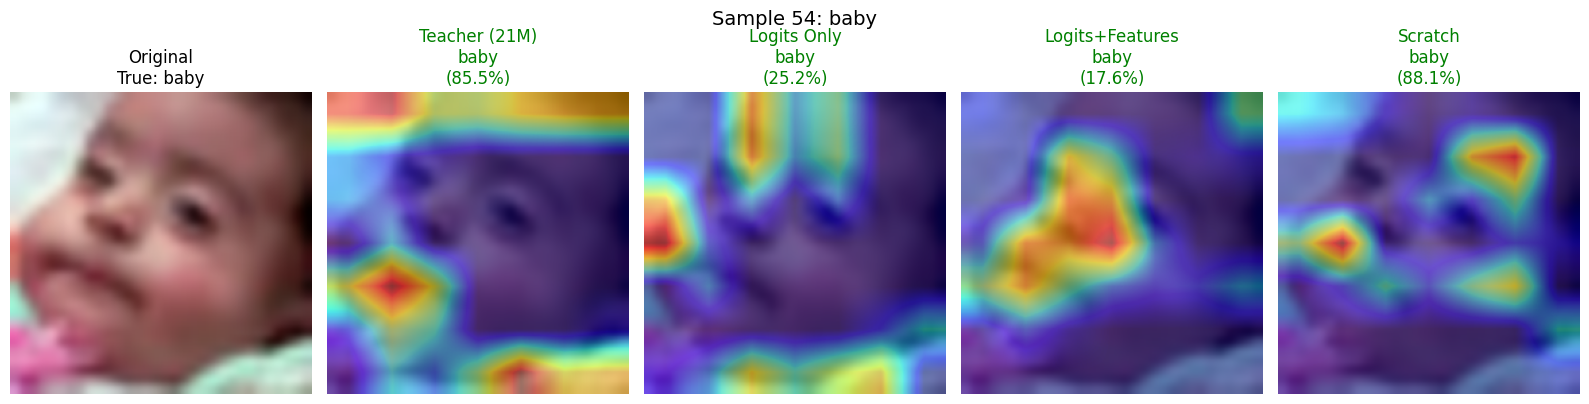


Prediction Summary:
  Teacher (21M): baby (85.5%) - correct
  Logits Only: baby (25.2%) - correct
  Logits+Features: baby (17.6%) - correct
  Scratch: baby (88.1%) - correct


In [32]:
#@title Compare on Single Sample

SAMPLE_INDEX = 54  #@param {type:"integer"}

image_tensor, original_image, true_label = get_sample(SAMPLE_INDEX)

print(f"Sample {SAMPLE_INDEX}: {CIFAR100_CLASSES[true_label]}")
print("="*50)

results = compare_models(
    registry=registry,
    image_tensor=image_tensor,
    original_image=original_image,
    true_label=true_label,
    sample_idx=SAMPLE_INDEX
)

# Print summary
print("\nPrediction Summary:")
for name, res in results.items():
    status = "correct" if res['correct'] else "wrong"
    print(f"  {name}: {CIFAR100_CLASSES[res['predicted']]} ({res['prob']*100:.1f}%) - {status}")

In [ ]:
#@title Compare on Multiple Samples

SAMPLE_INDICES = [10, 42, 100, 250, 500]  #@param {type:"raw"}

for idx in SAMPLE_INDICES:
    image_tensor, original_image, true_label = get_sample(idx)
    
    compare_models(
        registry=registry,
        image_tensor=image_tensor,
        original_image=original_image,
        true_label=true_label,
        sample_idx=idx
    )
    print()

In [ ]:
#@title Detailed View with Separate Heatmaps

SAMPLE_INDEX = 42  #@param {type:"integer"}

image_tensor, original_image, true_label = get_sample(SAMPLE_INDEX)

compare_models_detailed(
    registry=registry,
    image_tensor=image_tensor,
    original_image=original_image,
    true_label=true_label,
    sample_idx=SAMPLE_INDEX
)

In [ ]:
#@title Find Interesting Samples (Where Models Disagree)

NUM_SAMPLES_TO_CHECK = 200  #@param {type:"integer"}

disagreements = []
model_names = registry.list_models()

print("Searching for samples where models disagree...")

for idx in range(NUM_SAMPLES_TO_CHECK):
    image_tensor, _, true_label = get_sample(idx)
    
    predictions = []
    for name in model_names:
        model = registry.get(name)
        with torch.no_grad():
            output = model(image_tensor)
        pred = output.argmax(dim=1).item()
        predictions.append(pred)
    
    # Check if predictions differ
    if len(set(predictions)) > 1:
        disagreements.append({
            'idx': idx,
            'true_label': true_label,
            'predictions': dict(zip(model_names, predictions))
        })

print(f"\nFound {len(disagreements)} samples with disagreement")
print("="*50)

# Show first few
for item in disagreements[:5]:
    print(f"Sample {item['idx']}: True = {CIFAR100_CLASSES[item['true_label']]}")
    for name, pred in item['predictions'].items():
        print(f"  {name}: {CIFAR100_CLASSES[pred]}")
    print()

In [ ]:
#@title Visualize Disagreement Samples

if disagreements:
    print("Visualizing samples where models disagree:")
    print("="*50)
    
    for item in disagreements[:3]:  # Show first 3
        idx = item['idx']
        image_tensor, original_image, true_label = get_sample(idx)
        
        compare_models_detailed(
            registry=registry,
            image_tensor=image_tensor,
            original_image=original_image,
            true_label=true_label,
            sample_idx=idx
        )
        print()
else:
    print("No disagreements found in checked samples.")

## 8. Quantitative Analysis

In [ ]:
#@title Compute Accuracy on Test Set

NUM_EVAL_SAMPLES = 1000  #@param {type:"integer"}

from tqdm import tqdm

model_names = registry.list_models()
accuracies = {name: 0 for name in model_names}

print(f"Evaluating on {NUM_EVAL_SAMPLES} samples...")

for idx in tqdm(range(NUM_EVAL_SAMPLES)):
    image_tensor, _, true_label = get_sample(idx)
    
    for name in model_names:
        model = registry.get(name)
        with torch.no_grad():
            output = model(image_tensor)
        pred = output.argmax(dim=1).item()
        if pred == true_label:
            accuracies[name] += 1

print("\nAccuracy Results:")
print("="*50)
for name, correct in accuracies.items():
    acc = 100 * correct / NUM_EVAL_SAMPLES
    print(f"{name}: {acc:.2f}% ({correct}/{NUM_EVAL_SAMPLES})")

In [ ]:
#@title Plot Accuracy Comparison

names = list(accuracies.keys())
accs = [100 * accuracies[n] / NUM_EVAL_SAMPLES for n in names]

colors = ['#2ecc71' if 'Teacher' in n else '#3498db' if 'Feature' in n else '#e74c3c' for n in names]

plt.figure(figsize=(10, 6))
bars = plt.bar(names, accs, color=colors, edgecolor='black')
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison on CIFAR-100 Test Set')
plt.ylim(0, 100)

# Add value labels
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

## 9. Save Results

In [ ]:
#@title Save GradCAM Visualizations

SAVE_DIR = "./gradcam_results"  #@param {type:"string"}
SAMPLES_TO_SAVE = [10, 42, 100, 250, 500]  #@param {type:"raw"}

import os
os.makedirs(SAVE_DIR, exist_ok=True)

model_names = registry.list_models()

for idx in SAMPLES_TO_SAVE:
    image_tensor, original_image, true_label = get_sample(idx)
    
    n_models = len(model_names)
    fig, axes = plt.subplots(1, n_models + 1, figsize=(4 * (n_models + 1), 4))
    
    # Original
    axes[0].imshow(original_image)
    axes[0].set_title(f"Original\n{CIFAR100_CLASSES[true_label]}")
    axes[0].axis('off')
    
    # Models
    for i, name in enumerate(model_names):
        model = registry.get(name)
        model_type = registry.get_model_type(name)
        
        target_layer = get_target_layer(model, model_type)
        spatial_size = get_spatial_size(model_type)
        gradcam_type = get_gradcam_model_type(model_type)
        
        grad_cam = GradCAM(model, target_layer, model_type=gradcam_type)
        
        with torch.no_grad():
            output = model(image_tensor)
        pred = output.argmax(dim=1).item()
        prob = F.softmax(output, dim=1)[0, pred].item()
        
        cam = grad_cam.generate_cam(image_tensor, pred, spatial_size)
        overlaid = overlay_cam_on_image(original_image, cam)
        
        axes[i + 1].imshow(overlaid)
        color = "green" if pred == true_label else "red"
        axes[i + 1].set_title(f"{name}\n{CIFAR100_CLASSES[pred]} ({prob*100:.1f}%)", color=color)
        axes[i + 1].axis('off')
        
        grad_cam.remove_hooks()
    
    plt.suptitle(f"Sample {idx}")
    plt.tight_layout()
    
    save_path = os.path.join(SAVE_DIR, f"gradcam_sample_{idx}.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"Saved: {save_path}")

print(f"\nAll visualizations saved to {SAVE_DIR}/")